In [1]:
import pandas as pd
import numpy as np
np.set_printoptions(threshold=10000, linewidth=10000)
import sklearn
import matplotlib.pyplot as plt

In [2]:
'''write train data to csv, with output column'''

#start with zero array to populate with NMR data
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../RMN/train/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #correct strings
    temp_df.T2_data = temp_df.T2_data.str.replace(",",".")
    temp_df.T2_data = temp_df.T2_data.str.replace(" ","").astype(float)/1000
    #clip at zero
    temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    #add row with contents of current file
    array = np.vstack((array,temp_df.T2_data))

scaler = sklearn.preprocessing.MinMaxScaler()
array = scaler.fit_transform(array.T).T
train_df = pd.DataFrame(array)

#adding y column to df
train_df['y'] = pd.read_csv("../RMN/train/Output/OilSat.csv", sep="\t")['Oil_Sat']

#writing to csv file
# train_df.to_csv("./data_train.csv", sep="\t", index=False)
# train_df

In [3]:
'''write test data to csv'''

#start with zero array to populate with NMR data
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../RMN/test/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #for test, no text correction, no clipping
    temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    array = np.vstack((array,temp_df.T2_data))
array = scaler.fit_transform(array.T).T
test_df = pd.DataFrame(array)
# test_df.to_csv("./data_test.csv", sep="\t", index=False)
# test_df

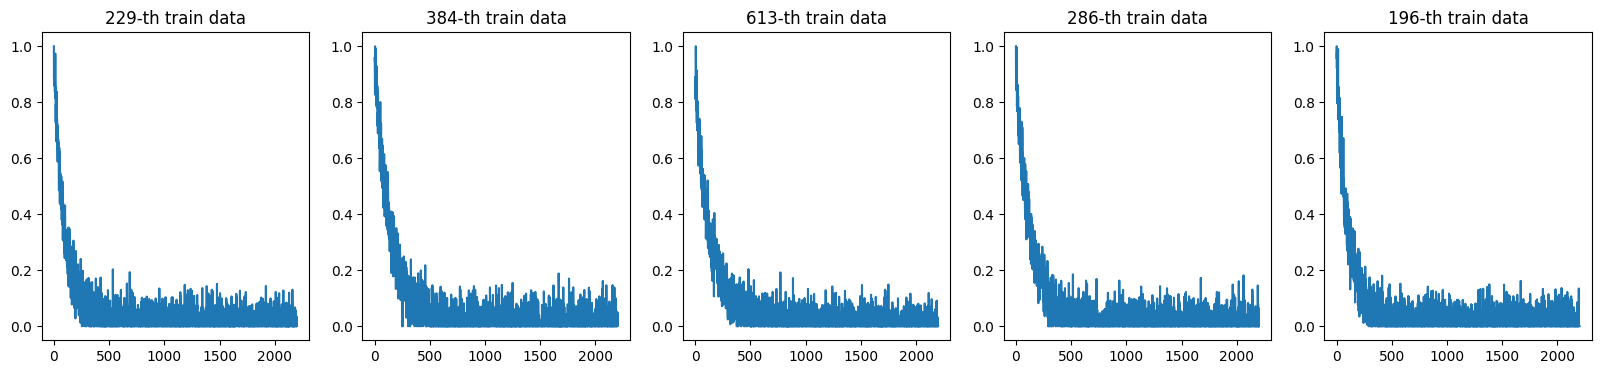

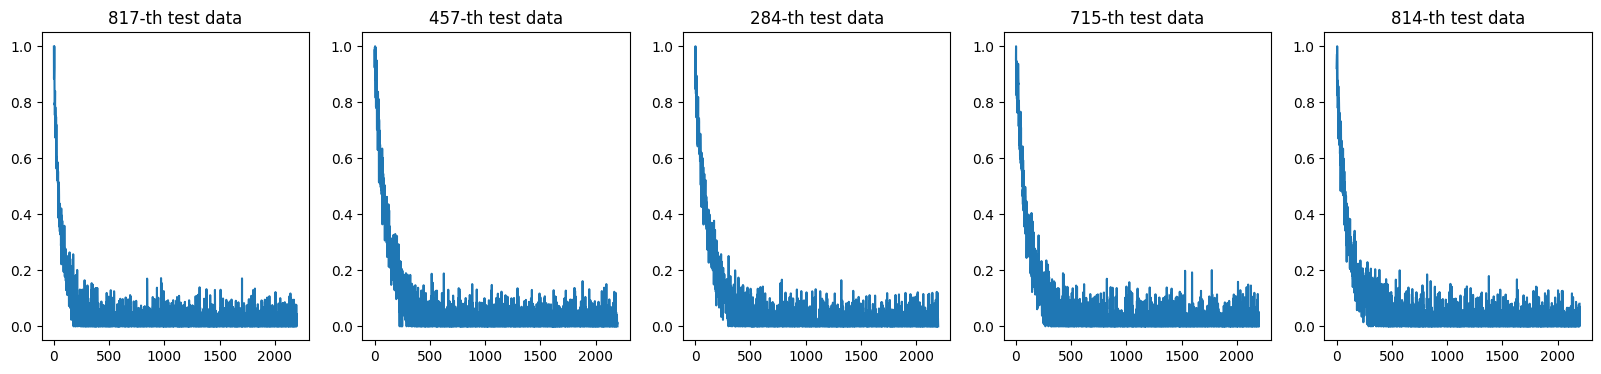

In [4]:
'''Plot graph of test and train after clip and normalization for comparison'''
fig, ax = plt.subplots(1,5, figsize=(20,4))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th train data")
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,4))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th test data")
plt.show();

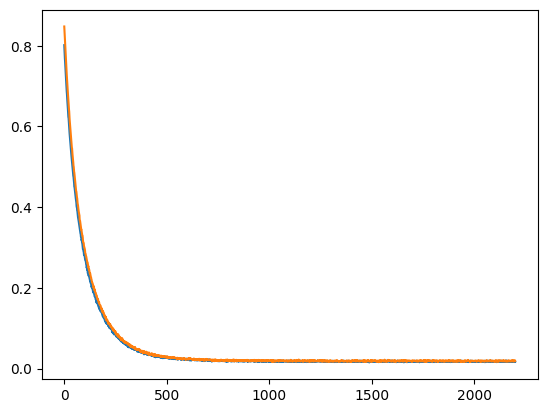

In [5]:
'''Plot to compare initial values (after normalization) for train and test sets'''
# plt.plot(train_df[0])
# plt.plot(test_df[0]);
plt.plot(train_df.drop(["y"], axis=1).mean())
plt.plot(test_df.mean());
# plt.yscale('log');

In [35]:
%pip install pywavelets

  Using cached pywavelets-1.8.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.0 kB)
Using cached pywavelets-1.8.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pywt
def DWTdenoise(noisy, wvlet='db4', level=4, mode='soft'):
    # DWT decomposition
    coeffs = pywt.wavedec(noisy, wvlet, level=level)#, mode='smooth')
    cA, cD = coeffs[0], coeffs[1:]

    # Estimate noise level (MAD)
    sigma = np.median(np.abs(cD[-1])) / 0.6745 *2
    T = sigma * np.sqrt(2 * np.log(len(noisy)))

    # Thresholding
    coeffs_thresh = [cA] + [pywt.threshold(cd, T, mode=mode) for cd in cD]

    # Return denoised signal
    return pywt.waverec(coeffs_thresh, wvlet), coeffs_thresh

Choosing DWT with wavelet 'db6' level 6. Why? On file preprocessing.ipynb

Visualmente, o level 6 apresenta os melhores resultados. Vou focar nele

In [16]:
import warnings
j = np.random.randint(1,1000,1)[0]
denoised_lvl6 = {}
for wvlet in ['db'+str(i) for i in range(6,7)] + ['sym'+str(i) for i in range(6,7)] + ['coif'+str(i) for i in range(2,3)] + ['dmey']:
    for level in range(6,7):
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning)
            denoised_lvl6[wvlet],_ = DWTdenoise(train_df.drop('y',axis=1).loc[j], wvlet, level=level, mode='soft')

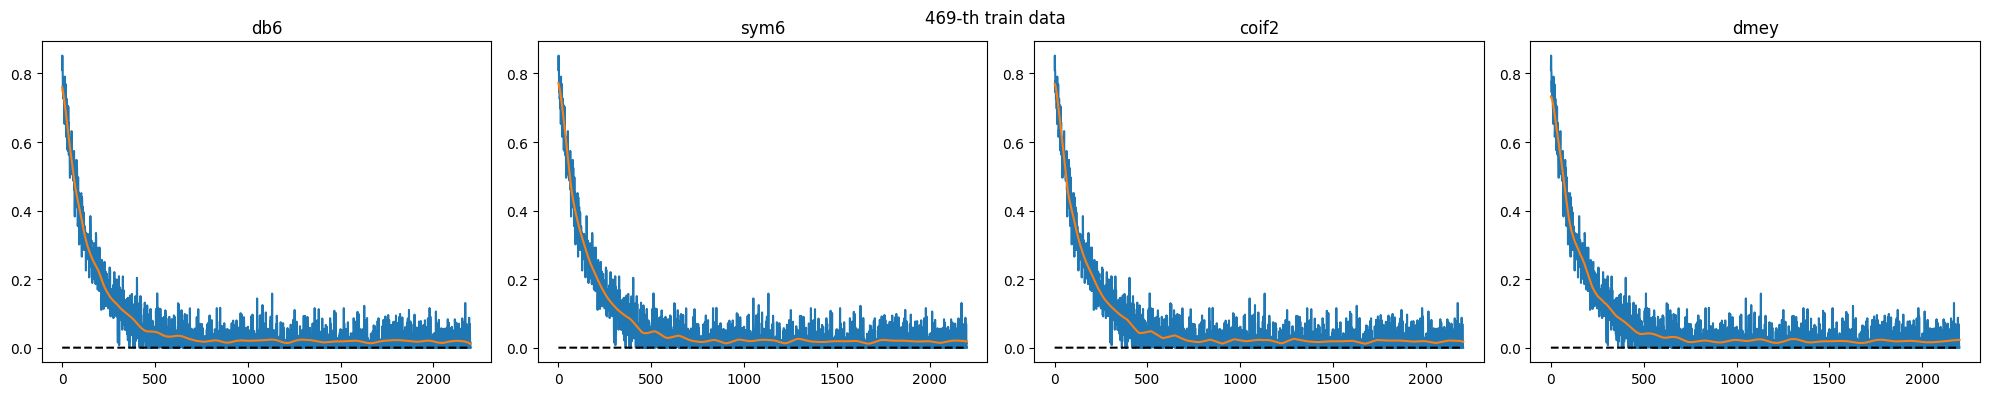

In [18]:
fig, ax = plt.subplots(1,4, figsize=(20,4))
ax = ax.flatten()
xaxis_length = len(denoised_lvl6['db6'])
for i,outDWT in enumerate(denoised_lvl6.items()):
    ax[i].plot(train_df.drop('y',axis=1).loc[j])
    ax[i].plot(outDWT[1])
    ax[i].set_title(f"{outDWT[0]}")
    ax[i].plot(range(xaxis_length),[0]*xaxis_length, 'k--');
plt.tight_layout()
fig.suptitle(f"{j}-th train data")
plt.subplots_adjust(top=0.9)
fig.show()

Podemos salvar as novas curvas assim:

In [291]:
array = np.array(train_df.drop('y',axis=1))
DWT_array = np.zeros((0,2202))
for i in range(len(train_df)):
    row,_ = DWTdenoise(array[i], 'db6', level=6)
    DWT_array = np.vstack((DWT_array,row))
train_DWT_df = pd.DataFrame(DWT_array)
train_DWT_df['y'] = train_df['y'].copy()
train_DWT_df.to_csv("./data_train_DWT_n.csv", sep="\t", index=False)
train_DWT_df.shape

(1000, 2203)

In [292]:
array = np.array(test_df)
DWT_array = np.zeros((0,2202))
for i in range(len(test_df)):
    row,_ = DWTdenoise(array[i], 'db6', level=6)
    DWT_array = np.vstack((DWT_array,row))
test_DWT_df = pd.DataFrame(DWT_array)
test_DWT_df.to_csv("./data_test_DWT_n.csv", sep="\t", index=False)
test_DWT_df.shape

(1000, 2202)

Porém podemos implementar uma filtragem melhor com um autoencoder antes do DWT:

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [7]:
X = torch.Tensor(np.vstack((train_df.iloc[:,:-1],test_df))).to(device)
y = X.to(device)

data_loader = DataLoader(TensorDataset(X, y), batch_size=256, shuffle=True)

In [8]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,X.shape[1]),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.191550
Epoch 20 | Train MSE: 0.003034
Epoch 40 | Train MSE: 0.002842
Epoch 60 | Train MSE: 0.002205
Epoch 80 | Train MSE: 0.001989
Epoch 100 | Train MSE: 0.001598
Epoch 120 | Train MSE: 0.001381
Epoch 140 | Train MSE: 0.001372
Epoch 160 | Train MSE: 0.001368
Epoch 180 | Train MSE: 0.001366
Epoch 200 | Train MSE: 0.001363
Epoch 220 | Train MSE: 0.001360
Epoch 240 | Train MSE: 0.001358
Epoch 260 | Train MSE: 0.001356
Epoch 280 | Train MSE: 0.001353
Epoch 300 | Train MSE: 0.001351
Epoch 320 | Train MSE: 0.001350
Epoch 340 | Train MSE: 0.001348
Epoch 360 | Train MSE: 0.001347
Epoch 380 | Train MSE: 0.001345
Epoch 400 | Train MSE: 0.001344
Epoch 420 | Train MSE: 0.001343
Epoch 440 | Train MSE: 0.001342
Epoch 460 | Train MSE: 0.001340
Epoch 480 | Train MSE: 0.001339


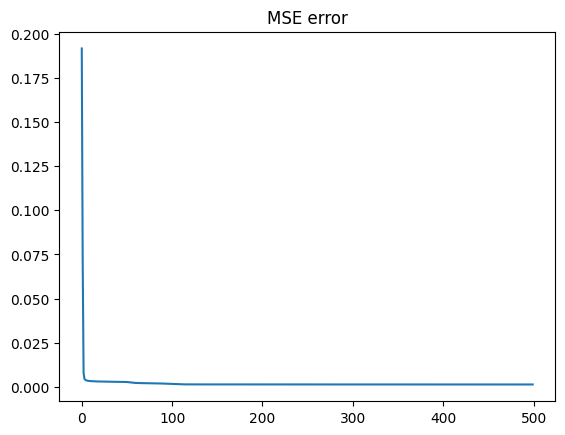

In [9]:
epochs = 500  #20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in data_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(data_loader.dataset)

    history.append(train_loss)

    if epoch%20==0: print(f"Epoch {epoch:002d} | Train MSE: {train_loss:.6f}")
plt.plot(history)
plt.title('MSE error')
plt.show()

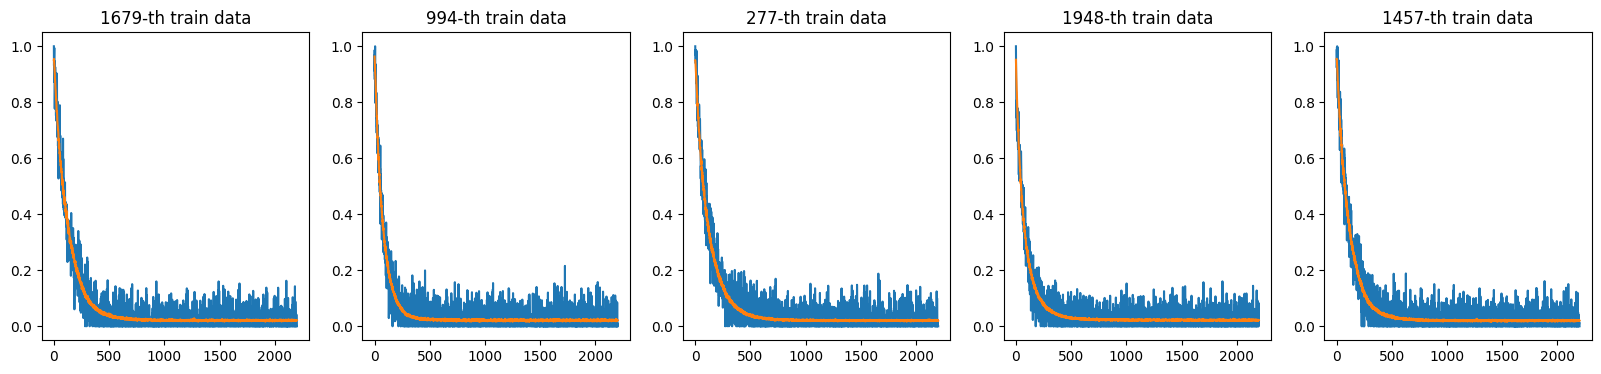

In [10]:
# Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(X).squeeze().detach().cpu().numpy()

fig, ax = plt.subplots(1,5, figsize=(20,4))
for i,j in enumerate(np.random.randint(1,len(X),5)):
    ax[i].plot(X.squeeze().detach().cpu().numpy()[j])
    ax[i].plot(y_pred[j])
    # ax[i].plot(np.convolve(y_pred[j],np.ones(5), mode='same')/np.convolve(np.ones_like(y_pred[j]),np.ones(5), mode="same")) #smoothed-out y_pred, edge-aware
    ax[i].set_title(f"{j}-th train data")
plt.show()

1457-th train data


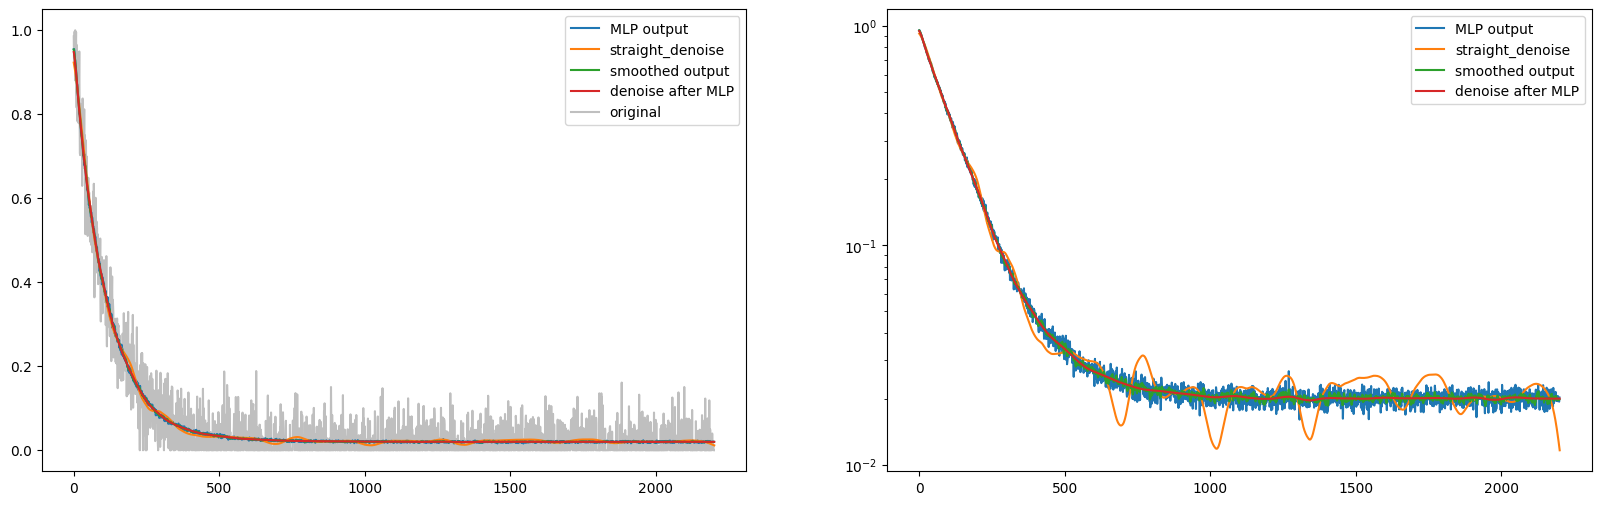

In [11]:
y_pred_DWTj,_ = DWTdenoise(y_pred[j], wvlet='db6', level=6)
y_DWTj     ,_ = DWTdenoise(X.squeeze().detach().cpu().numpy()[j], wvlet='db6', level=6)

fig, (ax0,ax1) = plt.subplots(1,2, figsize=(20,6))

ax0.plot(y_pred[j], label="MLP output")
ax0.plot(y_DWTj, label="straight_denoise")
ax0.plot(np.convolve(y_pred[j],np.ones(5), mode='same')/np.convolve(np.ones_like(y_pred[j]),np.ones(5), mode="same"), label="smoothed output")
ax0.plot(y_pred_DWTj, label="denoise after MLP")
ax0.plot(X.squeeze().detach().cpu().numpy()[j], label="original", zorder=0, c='gray', alpha=.5)
# ax.yscale('log')
ax0.legend();

ax1.plot(y_pred[j], label="MLP output")
ax1.plot(y_DWTj, label="straight_denoise")
ax1.plot(np.convolve(y_pred[j],np.ones(5), mode='same')/np.convolve(np.ones_like(y_pred[j]),np.ones(5), mode="same"), label="smoothed output")
ax1.plot(y_pred_DWTj, label="denoise after MLP")
ax1.set_yscale('log')
ax1.legend();
print(f"{j}-th train data")
plt.show()

In [12]:
array = y_pred
DWT_array = np.zeros((0,2202))
for i in range(len(y_pred)):
    row,_ = DWTdenoise(array[i], 'db6', level=6)
    DWT_array = np.vstack((DWT_array,row))
train_df_autoDWT = pd.DataFrame(DWT_array[:1000])
train_df_autoDWT['y'] = train_df['y']
train_df_autoDWT.to_csv("./data_train_autoDWT_n.csv", sep="\t", index=False)

test_df_autoDWT = pd.DataFrame(DWT_array[1000:])
test_df_autoDWT.to_csv("./data_test_autoDWT_n.csv", sep="\t", index=False)

train_df_autoDWT.shape, test_df_autoDWT.shape

((1000, 2203), (1000, 2202))

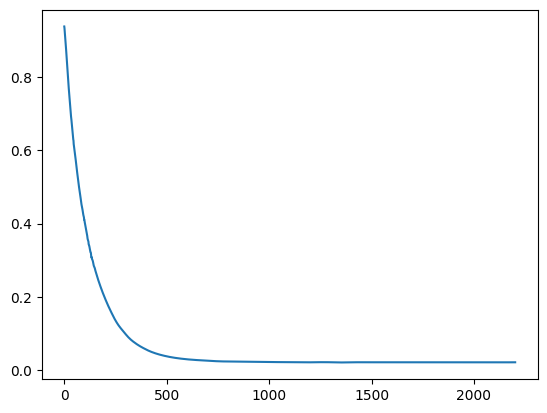

In [13]:
plt.plot(train_df_autoDWT.iloc[45,:-1]);

In [28]:
train_df_autoDWT.iloc[275,:-1].max()

np.float64(0.9376424239433183)

Salvando um arquivo com as features do DWT, sem reconstruir a curva

In [123]:
array = y_pred
# DWT_array = np.zeros((0,2202))
for i in range(879,880):
    _, coeffs_thresh = DWTdenoise(array[i], 'db6', level=6)
[c.shape for c in coeffs_thresh], coeffs_thresh


    
    # DWT_array = np.vstack((DWT_array,row))
# train_df_autoDWT = pd.DataFrame(DWT_array[:1000])
# train_df_autoDWT['y'] = train_df['y']
# train_df_autoDWT.to_csv("./data_train_autoDWT.csv", sep="\t", index=False)

# test_df_autoDWT = pd.DataFrame(DWT_array[1000:])
# test_df_autoDWT.to_csv("./data_test_autoDWT.csv", sep="\t", index=False)

# train_df_autoDWT.shape, test_df_autoDWT.shape

([(45,), (45,), (79,), (147,), (284,), (558,), (1106,)],
 [array([5.773353  , 5.8040304 , 5.8020716 , 5.807837  , 5.7840075 , 5.803592  , 5.8244524 , 5.732542  , 6.025589  , 4.509428  , 2.7019355 , 1.6725829 , 1.0007827 , 0.6192237 , 0.43364516, 0.3205036 , 0.25740567, 0.1993847 , 0.17270693, 0.16093668, 0.14793591, 0.14933988, 0.1361713 , 0.13029651, 0.12391664, 0.14102903, 0.1279015 , 0.12289263, 0.13207442, 0.11682374, 0.11907075, 0.12712583, 0.12528865, 0.1262109 , 0.11632927, 0.12272336, 0.12202808, 0.11862077, 0.11981511, 0.12341966, 0.13172525, 0.12526336, 0.1207727 , 0.08321986, 0.08080197], dtype=float32),
  array([ 0.        , -0.        , -0.        ,  0.        ,  0.0579491 , -0.        ,  0.02132133, -0.        ,  0.        ,  0.        , -0.        , -0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        , -0.        ,  0.        ,  0.        ,  0.        ,  0.        , -0.        , -0.        , -0.        , -0.        ,  0.        , -0.        ,  0. 

Vamos salvar a primeira componente da decomposição como features

In [124]:
y_pred.shape

(2000, 2201)

In [128]:
array = y_pred
out_array = np.zeros((0,45))

for j in range(1000):
    _, coeffs_thresh = DWTdenoise(array[j], 'db6', level=6)
    out_array = np.vstack((out_array,coeffs_thresh[0]))
autoDWT_train_df = pd.DataFrame(out_array)
autoDWT_train_df['y'] = train_df['y']

out_array = np.zeros((0,45))
for j in range(1000,2000):
    _, coeffs_thresh = DWTdenoise(array[j], 'db6', level=6)
    out_array = np.vstack((out_array,coeffs_thresh[0]))
autoDWT_test_df = pd.DataFrame(out_array)

autoDWT_train_df.to_csv('data_train_autoDWTfeat.csv', sep="\t", index=False)
autoDWT_test_df .to_csv('data_test_autoDWTfeat.csv', sep="\t", index=False)
autoDWT_train_df

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,y
0,6.059945,6.104476,6.099446,6.111925,6.069283,6.107776,6.122828,6.027696,6.354362,4.466894,...,0.151555,0.145856,0.145391,0.151748,0.140910,0.133380,0.142388,0.105734,0.102420,0.29
1,6.154316,6.198442,6.195603,6.202806,6.172101,6.196209,6.226088,6.108373,6.474806,4.472358,...,0.140888,0.140910,0.136767,0.130380,0.127612,0.158370,0.142640,0.174997,0.174106,0.30
2,6.029055,6.068427,6.062307,6.078429,6.030485,6.076102,6.079618,6.006508,6.283432,4.597682,...,0.173462,0.147569,0.160456,0.150261,0.151373,0.145495,0.150433,0.165263,0.170402,0.11
3,5.947324,5.997208,5.988881,6.011418,5.949153,6.007287,6.016138,5.905885,6.305490,3.953542,...,0.155332,0.142336,0.143622,0.146128,0.132532,0.154561,0.141728,0.122304,0.113408,0.61
4,6.043510,6.098491,6.093070,6.106622,6.059358,6.099062,6.128303,5.993411,6.429177,3.965122,...,0.136907,0.123824,0.146701,0.137519,0.138161,0.124236,0.130759,0.121016,0.120772,0.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,6.022833,6.062309,6.054403,6.073337,6.022423,6.068415,6.080581,5.977608,6.335639,4.371648,...,0.142798,0.137082,0.135751,0.137825,0.138014,0.131847,0.132110,0.103709,0.103844,0.33
996,6.037769,6.083477,6.072998,6.101639,6.030781,6.100039,6.092830,6.006995,6.364295,4.165945,...,0.127428,0.134617,0.139838,0.147191,0.138231,0.127809,0.145665,0.134552,0.137280,0.29
997,5.809929,5.864120,5.857818,5.872409,5.822078,5.866701,5.884096,5.785649,6.120718,4.022150,...,0.131934,0.146389,0.143601,0.129606,0.142025,0.144431,0.148393,0.118466,0.120716,0.36
998,6.040887,6.091571,6.082433,6.107646,6.040276,6.103949,6.109211,6.000475,6.404004,3.990399,...,0.132971,0.137199,0.135964,0.150922,0.141639,0.152629,0.150861,0.168686,0.170437,0.69


In [127]:
autoDWT_test_df

,0,1,2,3,4,5,6,7,8,9,...,35,36,37,38,39,40,41,42,43,44
0,6.514597,6.566909,6.559550,6.579095,6.518997,6.574543,6.586162,6.480175,6.857273,4.576597,...,0.141295,0.141511,0.138999,0.132763,0.139551,0.134068,0.155850,0.145654,0.221597,0.217363
1,6.268269,6.331178,6.323235,6.343593,6.275455,6.337562,6.354365,6.231804,6.665012,4.023602,...,0.135120,0.139404,0.140103,0.136562,0.135077,0.136358,0.144787,0.144276,0.128472,0.125580
2,6.656245,6.695931,6.689389,6.706449,6.657189,6.702938,6.711877,6.619332,6.949845,5.073204,...,0.149126,0.151743,0.162612,0.148179,0.153394,0.145777,0.147253,0.149253,0.145274,0.142480
3,6.423369,6.462189,6.456729,6.470953,6.428859,6.465602,6.486983,6.363770,6.769763,4.681167,...,0.155154,0.162934,0.184572,0.157245,0.160706,0.150787,0.154022,0.157454,0.163497,0.156859
4,6.246367,6.276067,6.270780,6.284657,6.248651,6.281592,6.291263,6.206557,6.500362,4.935674,...,0.151167,0.159938,0.154491,0.141545,0.137190,0.148631,0.147640,0.146342,0.146868,0.152139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,6.417689,6.464491,6.459555,6.471078,6.430136,6.465564,6.485865,6.384264,6.719519,4.772553,...,0.137381,0.126760,0.142089,0.144164,0.122691,0.138512,0.143771,0.126143,0.128417,0.129861
996,6.267459,6.337476,6.327542,6.353847,6.271577,6.350492,6.352595,6.247754,6.663861,3.916883,...,0.170644,0.135791,0.158627,0.159182,0.148733,0.153155,0.141416,0.168618,0.166184,0.175799
997,6.457771,6.498470,6.489768,6.512836,6.452456,6.512204,6.504791,6.435726,6.727426,4.928396,...,0.147189,0.133644,0.135073,0.145390,0.146513,0.131636,0.141755,0.144025,0.155324,0.148348
998,6.481724,6.525791,6.518672,6.537085,6.482047,6.534707,6.537783,6.455828,6.766993,4.891342,...,0.135982,0.149668,0.136242,0.132302,0.143540,0.137649,0.132183,0.156491,0.121653,0.125026


Salvar as três primeiras componentes da decomposição como features adiciona muito ruído, não ajuda...

In [297]:
train_df['y'].describe()

count    1000.000000
mean        0.397510
std         0.229629
min         0.000000
25%         0.210000
50%         0.390000
75%         0.600000
max         0.800000
Name: y, dtype: float64

Alternativa: Savgol filter

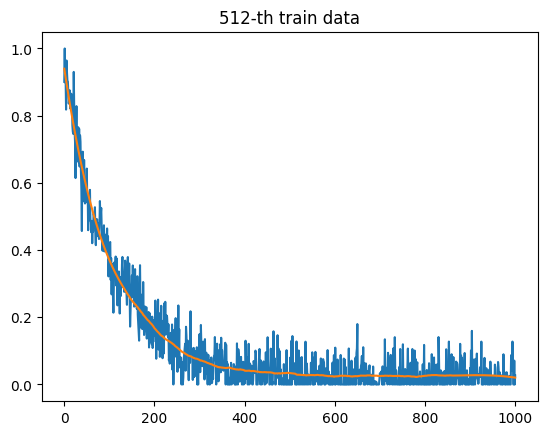

In [23]:
import scipy as sp
from scipy.signal import savgol_filter

j = np.random.randint(1,1000,1)[0]
# signal = train_df.drop('y',axis=1).loc[j,:1000]
signal = test_df.loc[j,:1000]
plt.plot(signal)
plt.plot(savgol_filter(signal, 271, 3))
plt.title(str(j)+"-th train data");

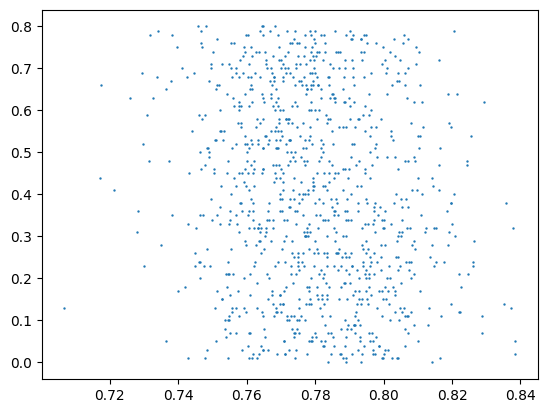

In [320]:
# train_df.iloc[:,0:5].mean(axis=1)
# plt.scatter(train_df.iloc[:,0:5].mean(axis=1), train_df['y'], s=.5)
# plt.show()
plt.scatter(train_df.iloc[:,:5].mean(axis=1), train_df['y'], s=.5)